### Sales Analysis

#### Question 2: What city sold the most product?

In [15]:
import pandas as pd
import matplotlib.pyplot as plt

In [11]:
all_data = pd.read_csv("../dataset/Sales_Data_Cleaned.csv")
all_data.head()

,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address
0,295665,Macbook Pro Laptop,1,1700.00,12/30/19 00:01,"136 Church St, New York City, NY 10001"
1,295666,LG Washing Machine,1,600.00,12/29/19 07:03,"562 2nd St, New York City, NY 10001"
2,295667,USB-C Charging Cable,1,11.95,12/12/19 18:21,"277 Main St, New York City, NY 10001"
3,295668,27in FHD Monitor,1,149.99,12/22/19 15:13,"410 6th St, San Francisco, CA 94016"
4,295669,USB-C Charging Cable,1,11.95,12/18/19 12:38,"43 Hill St, Atlanta, GA 30301"


In [12]:
def get_city(address):
    return address.split(",")[1].strip()

def get_state(address):
    return address.split(",")[2].split(" ")[1]


all_data["City"] = all_data["Purchase Address"].apply(lambda x: f"{get_city(x)} ({get_state(x)})")

In [13]:
all_data.head()

,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address,City
0,295665,Macbook Pro Laptop,1,1700.00,12/30/19 00:01,"136 Church St, New York City, NY 10001",New York City (NY)
1,295666,LG Washing Machine,1,600.00,12/29/19 07:03,"562 2nd St, New York City, NY 10001",New York City (NY)
2,295667,USB-C Charging Cable,1,11.95,12/12/19 18:21,"277 Main St, New York City, NY 10001",New York City (NY)
3,295668,27in FHD Monitor,1,149.99,12/22/19 15:13,"410 6th St, San Francisco, CA 94016",San Francisco (CA)
4,295669,USB-C Charging Cable,1,11.95,12/18/19 12:38,"43 Hill St, Atlanta, GA 30301",Atlanta (GA)


In [14]:
all_data.groupby("City")['Quantity Ordered'].sum()

City
Atlanta (GA)          16602
Austin (TX)           11153
Boston (MA)           22528
Dallas (TX)           16730
Los Angeles (CA)      33289
New York City (NY)    27932
Portland (ME)          2750
Portland (OR)         11303
San Francisco (CA)    50239
Seattle (WA)          16553
Name: Quantity Ordered, dtype: int64

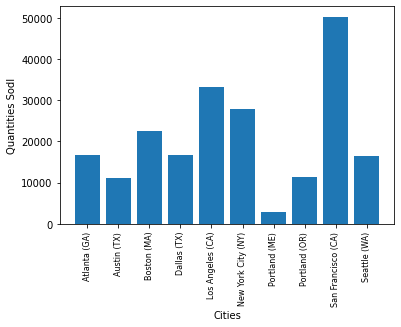

In [17]:
cities = [city for city, df in all_data.groupby('City')]

plt.bar(cities, all_data.groupby("City")['Quantity Ordered'].sum())
plt.ylabel('Quantities Sodl')
plt.xlabel('Cities')
plt.xticks(cities, rotation='vertical', size=8)
plt.show()